# MNIST Binary Benchmark — CrossCat Paper Section 3.2 Reproduction

Reproduces the MNIST experiments from:
> Mansinghka et al. (2016) "CrossCat: A Fully Bayesian Nonparametric Method for Analyzing Heterogeneous, High Dimensional Data", JMLR 17(1):1-49.

**Paper setup (Section 3.2):**
- 16×16 downsampled MNIST → 256 binary pixels (BetaBernoulli) + digit label (Categorical)
- 10 posterior samples, each 1000 Gibbs iterations
- Evaluations: Z-matrix (Fig 13b), pixel dependence map (Fig 13c), classification ROC (Fig 15), pixel inpainting (Fig 14)

**Platform-agnostic** — auto-detects Colab, Kaggle, or local GPU and configures accordingly.
Automatically scales chain count when multiple GPUs are available.

**Instructions:**
1. Upload to **Kaggle** (P100/T4) or **Colab** (T4/A100) or run locally with GPU
2. Run all cells
3. States are checkpointed — if the session dies, re-run and it resumes from the last checkpoint

## 1. Setup

In [1]:
!nvidia-smi

Tue Apr  7 20:37:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

WORKDIR = "/kaggle/working/jaxcross"
BRANCH = "main"  # @param {type:"string"}

!git clone https://github.com/sambhal-labs/jaxcross.git {WORKDIR} 2>/dev/null \
    || (cd {WORKDIR} && git pull)
os.chdir(WORKDIR)

!git fetch origin && (git checkout {BRANCH} || git checkout -b {BRANCH} origin/{BRANCH}) && git pull origin {BRANCH}

%pip install -e . --no-deps -q
%pip install scikit-learn matplotlib -q

print(f"Branch: {BRANCH}")
print(f"Working directory: {os.getcwd()}")
print("Setup complete.")

Already up to date.
M	paper/generate_figures.sh
Already on 'chore/benchmark-consolidation'
Your branch is up to date with 'origin/chore/benchmark-consolidation'.
From https://github.com/sambhal-labs/jaxcross
 * branch            chore/benchmark-consolidation -> FETCH_HEAD
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jax-crosscat (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Branch: chore/benchmark-consolidation
Working directory: /kaggle/working/jaxcross
Setup complete.


## 2. Imports & Platform Detection

In [3]:
import gc
import json
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import fetch_openml
from sklearn.metrics import auc, roc_curve
from sklearn.svm import SVC

import crosscat
import crosscat.packed.state as _ps
from crosscat import (
    ColumnType,
    collect_diagnostics,
    initialize,
    load_state,
    pack_state,
    packed_gibbs_sweep,
    packed_log_joint,
    save_checkpoint,
    save_state,
    unpack_state,
)
from crosscat.packed import batch_packed_states
from crosscat.packed_inference import (
    batch_classify_column,
    batch_score_columns_binary,
    packed_dependence_matrix,
)

print(f"jaxcross {crosscat.__version__}")
print(f"JAX {jax.__version__} | Backend: {jax.default_backend()} | Devices: {jax.devices()}")

n_devices = jax.device_count()
n_gpus = n_devices
print(f"Devices: {n_devices} ({jax.devices()})")
USE_PMAP = n_devices > 1
print(f"Multi-GPU (pmap): {USE_PMAP}")
assert jax.default_backend() in ("gpu", "tpu"), "This notebook requires GPU/TPU runtime!"

jaxcross 0.11.0
JAX 0.7.2 | Backend: gpu | Devices: [CudaDevice(id=0), CudaDevice(id=1)]
Devices: 2 ([CudaDevice(id=0), CudaDevice(id=1)])
Multi-GPU (pmap): True


## 3. Configuration

| Parameter | T4 (16GB) | P100 (16GB) | A100 (40GB) | Paper |
|-----------|-----------|-------------|-------------|-------|
| `PIXEL_SIZE` | 16 | 16 | 16 | 16 |
| `N_SAMPLES` | 1000 | 1000 | 2000 | ~60,000 |
| `N_CHAINS` | 4 | 4 | 8 | 10 |
| `N_SWEEPS` | 500 | 500 | 800 | 1000 |

In [4]:
# ---- Benchmark Configuration ----
PIXEL_SIZE = 16  # Paper: 16x16 pixels
N_SAMPLES = 100  # Stratified: 100 per digit
N_CHAINS = 8 if USE_PMAP else 4
N_SWEEPS = 1000
SEED = 42

N_PIXELS = PIXEL_SIZE * PIXEL_SIZE
N_COLS = N_PIXELS + 1  # pixels + digit label

diag_interval = max(1, N_SWEEPS // 10)
ckpt_interval = max(1, N_SWEEPS // 5)

CHAINS_PER_DEVICE = N_CHAINS // n_devices
N_CHAINS = CHAINS_PER_DEVICE * n_devices  # round to divisible
assert CHAINS_PER_DEVICE >= 1, f"Need at least 1 chain per device: N_CHAINS must be >= n_devices ({n_devices})"

print(f"Config: {PIXEL_SIZE}x{PIXEL_SIZE} ({N_PIXELS} pixels + 1 digit = {N_COLS} cols)")
print(f"  {N_SAMPLES} samples, {N_CHAINS} chains x {N_SWEEPS} sweeps")
print(f"  {CHAINS_PER_DEVICE} chains/device, {n_devices} devices")
print(f"  diag_interval={diag_interval}, ckpt_interval={ckpt_interval}")

Config: 16x16 (256 pixels + 1 digit = 257 cols)
  100 samples, 8 chains x 1000 sweeps
  4 chains/device, 2 devices
  diag_interval=100, ckpt_interval=200


## 4. Data Loading & Preprocessing

Download MNIST, downsample to `PIXEL_SIZE x PIXEL_SIZE`, binarize, and append digit label as a categorical column.

Fetching MNIST...
Data: (100, 257) (256 binary pixels + 1 categorical digit)
Pixel density: 0.197


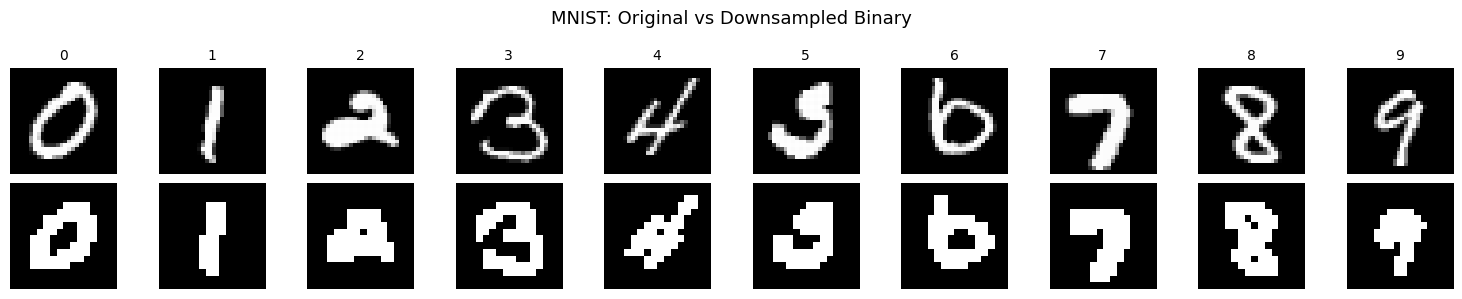

In [5]:
# Fetch MNIST with stratified sampling
print("Fetching MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
images_all = mnist.data.astype(np.float32)
labels_all = mnist.target.astype(np.int32)

rng = np.random.default_rng(SEED)
per_digit = N_SAMPLES // 10
indices = []
for digit in range(10):
    digit_idx = np.where(labels_all == digit)[0]
    chosen = rng.choice(digit_idx, size=min(per_digit, len(digit_idx)), replace=False)
    indices.append(chosen)
indices = np.concatenate(indices)
rng.shuffle(indices)
images, labels = images_all[indices], labels_all[indices]

# Downsample and binarize
n = images.shape[0]
imgs_28 = images.reshape(n, 28, 28)
if PIXEL_SIZE == 16:
    padded = np.zeros((n, 32, 32), dtype=np.float32)
    padded[:, 2:30, 2:30] = imgs_28
    block = 2
elif PIXEL_SIZE == 8:
    padded = imgs_28[:, 2:26, 2:26]  # trim to 24x24
    block = 3
elif PIXEL_SIZE == 7:
    padded = imgs_28
    block = 4
else:
    raise ValueError(f"Unsupported PIXEL_SIZE={PIXEL_SIZE}")

reshaped = padded.reshape(n, PIXEL_SIZE, block, PIXEL_SIZE, block)
downsampled = reshaped.mean(axis=(2, 4))
binary_images = (downsampled > 0.5).astype(np.float32).reshape(n, N_PIXELS)

# Append digit label as last column
data = np.hstack([binary_images, labels.astype(np.float32).reshape(-1, 1)])
col_types = [ColumnType.BINARY] * N_PIXELS + [ColumnType.CATEGORICAL]
data_jax = jnp.array(data)

print(f"Data: {data.shape} ({N_PIXELS} binary pixels + 1 categorical digit)")
print(f"Pixel density: {binary_images.mean():.3f}")

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    idx = np.where(labels == digit)[0][0]
    axes[0, digit].imshow(imgs_28[idx], cmap="gray")
    axes[0, digit].set_title(f"{digit}", fontsize=10)
    axes[0, digit].axis("off")
    axes[1, digit].imshow(binary_images[idx].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap="gray")
    axes[1, digit].axis("off")
axes[0, 0].set_ylabel("28x28", fontsize=9)
axes[1, 0].set_ylabel(f"{PIXEL_SIZE}x{PIXEL_SIZE}", fontsize=9)
fig.suptitle("MNIST: Original vs Downsampled Binary", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Gibbs Inference with Checkpointing

Multi-chain collapsed Gibbs sampling with automatic checkpointing and resume.
If the session dies, re-run this cell — it resumes from the last checkpoint.

In [6]:
CKPT_DIR = Path("benchmarks/results/mnist/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("benchmarks/results/mnist")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# --- Define pmap sweep function ---
def _sweep_one_chain(key, packed, data, n_sweeps):
    """Run n_sweeps of packed Gibbs on a single chain."""
    return packed_gibbs_sweep(key, packed, data, n_sweeps=n_sweeps)


def _sweep_chains_on_device(keys, packed_batch, data, n_sweeps):
    """Run sweeps for CHAINS_PER_DEVICE chains on one device."""

    def body(i, carry):
        packed_b = carry
        single_kwargs = {}
        for name in _ps._ARRAY_FIELDS:
            single_kwargs[name] = getattr(packed_b, name)[i]
        for name in _ps._STATIC_FIELDS:
            single_kwargs[name] = getattr(packed_b, name)
        single = _ps.PackedCrossCatState(**single_kwargs)
        result = _sweep_one_chain(keys[i], single, data, n_sweeps)
        new_kwargs = {}
        for name in _ps._ARRAY_FIELDS:
            arr = getattr(packed_b, name)
            new_kwargs[name] = arr.at[i].set(getattr(result, name))
        for name in _ps._STATIC_FIELDS:
            new_kwargs[name] = getattr(packed_b, name)
        return _ps.PackedCrossCatState(**new_kwargs)

    return jax.lax.fori_loop(0, keys.shape[0], body, packed_batch)


pmap_sweep = jax.pmap(
    _sweep_chains_on_device,
    in_axes=(0, 0, None, None),
    static_broadcasted_argnums=(3,),
)


def _prepare_pmap(all_packed, chain_keys):
    """Batch chains and reshape for pmap."""
    batched = batch_packed_states(all_packed)
    keys_pmap = chain_keys.reshape(n_devices, CHAINS_PER_DEVICE, *chain_keys.shape[1:])
    kwargs = {}
    for name in _ps._ARRAY_FIELDS:
        arr = getattr(batched, name)
        kwargs[name] = arr.reshape((n_devices, CHAINS_PER_DEVICE) + arr.shape[1:])
    for name in _ps._STATIC_FIELDS:
        kwargs[name] = getattr(batched, name)
    return keys_pmap, _ps.PackedCrossCatState(**kwargs)


def _unflatten_pmap(result_pmap, n_chains):
    """Extract individual packed states from pmap result."""
    out = []
    for c in range(n_chains):
        dev_idx = c // CHAINS_PER_DEVICE
        chain_idx = c % CHAINS_PER_DEVICE
        kwargs = {}
        for name in _ps._ARRAY_FIELDS:
            kwargs[name] = getattr(result_pmap, name)[dev_idx][chain_idx]
        for name in _ps._STATIC_FIELDS:
            kwargs[name] = getattr(result_pmap, name)
        out.append(_ps.PackedCrossCatState(**kwargs))
    return out


# --- Initialize chains ---
rng_key = jax.random.key(SEED)
init_keys = jax.random.split(rng_key, N_CHAINS)

all_packed = []
all_chain_metrics = []
all_sweep_keys = []
loaded_chains = set()

for chain_idx in range(N_CHAINS):
    chain_result_path = RESULTS_DIR / f"chain_{chain_idx + 1}"
    k_i, k_sweep = jax.random.split(init_keys[chain_idx])
    all_sweep_keys.append(k_sweep)

    if chain_result_path.with_suffix(".jxc").exists():
        print(f"Chain {chain_idx + 1}: LOADED from {chain_result_path}.jxc")
        state = load_state(chain_result_path, data=data_jax)
        all_packed.append(pack_state(state))
        loaded_chains.add(chain_idx)
        all_chain_metrics.append([])
        del state
    else:
        state = initialize(k_i, data_jax, col_types).state
        all_packed.append(pack_state(state))
        all_chain_metrics.append([])
        print(f"Chain {chain_idx + 1}: initialized ({state.n_views} views)")
        del state

gc.collect()

# --- pmap Gibbs sweep loop ---
if len(loaded_chains) == N_CHAINS:
    print("\nAll chains loaded from disk — skipping inference")
else:
    print(
        f"\nRunning {N_SWEEPS} sweeps on {N_CHAINS} chains ({CHAINS_PER_DEVICE}/device, {n_devices} devices)"
    )
    t_total = time.time()
    sweep = 0

    while sweep < N_SWEEPS:
        batch = min(diag_interval, N_SWEEPS - sweep)

        # Split keys for this batch
        chain_keys = []
        for c in range(N_CHAINS):
            all_sweep_keys[c], subkey = jax.random.split(all_sweep_keys[c])
            chain_keys.append(subkey)
        chain_keys = jnp.stack(chain_keys)

        # pmap sweep
        keys_pmap, batched_pmap = _prepare_pmap(all_packed, chain_keys)
        t0 = time.time()
        result_pmap = pmap_sweep(keys_pmap, batched_pmap, data_jax, batch)
        jax.tree.map(lambda x: x.block_until_ready(), result_pmap)
        sweep_time = time.time() - t0
        sweep += batch

        # Unflatten
        all_packed = _unflatten_pmap(result_pmap, N_CHAINS)

        # Diagnostics per chain
        for c in range(N_CHAINS):
            if c in loaded_chains:
                continue
            state_tmp = unpack_state(all_packed[c], col_types, data=data_jax)
            diag = collect_diagnostics(state_tmp, data_jax)
            n_views = state_tmp.n_views
            all_chain_metrics[c].append({"sweep": sweep, **diag})
            del state_tmp

        # Print progress
        ljs = [
            all_chain_metrics[c][-1]["log_joint"]
            for c in range(N_CHAINS)
            if c not in loaded_chains and all_chain_metrics[c]
        ]
        elapsed = time.time() - t_total
        print(
            f"  Sweep {sweep:4d}/{N_SWEEPS}: {sweep_time:.1f}s, "
            f"log_joints=[{', '.join(f'{lj:.0f}' for lj in ljs)}], elapsed={elapsed:.0f}s"
        )

        # Checkpoint
        if sweep % ckpt_interval == 0:
            for c in range(N_CHAINS):
                if c in loaded_chains:
                    continue
                chain_ckpt_dir = CKPT_DIR / f"chain_{c + 1}"
                save_checkpoint(
                    all_packed[c],
                    chain_ckpt_dir,
                    sweep,
                    column_types=col_types,
                    log_joint_value=float(all_chain_metrics[c][-1]["log_joint"]),
                )

    total_time = time.time() - t_total
    print(f"\nTotal inference: {total_time:.1f}s ({total_time / N_SWEEPS:.2f}s/sweep)")

    # Save final states
    for c in range(N_CHAINS):
        if c in loaded_chains:
            continue
        state = unpack_state(all_packed[c], col_types, data=data_jax)
        save_state(state, RESULTS_DIR / f"chain_{c + 1}")
        del state

# Build final lists
states = [unpack_state(p, col_types, data=data_jax) for p in all_packed]
packed_states = all_packed
scores = [float(packed_log_joint(p, data_jax)) for p in packed_states]
best_idx = int(np.argmax(scores))
print(f"\nBest chain: {best_idx + 1} (log_joint={scores[best_idx]:.0f})")
gc.collect()

Chain 1: initialized (3 views)
Chain 2: initialized (5 views)
Chain 3: initialized (4 views)
Chain 4: initialized (5 views)
Chain 5: initialized (8 views)
Chain 6: initialized (5 views)
Chain 7: initialized (5 views)
Chain 8: initialized (3 views)

Running 1000 sweeps on 8 chains (4/device, 2 devices)
  Sweep  100/1000: 272.7s, log_joints=[-6154, -6091, -6156, -6127, -6065, -6164, -6210, -6132], elapsed=436s
  Sweep  200/1000: 249.7s, log_joints=[-6095, -6131, -6057, -5914, -6070, -6189, -6410, -6153], elapsed=867s
  Sweep  300/1000: 248.8s, log_joints=[-6098, -6087, -5970, -5943, -6001, -6107, -6251, -6098], elapsed=1285s
  Sweep  400/1000: 249.7s, log_joints=[-6080, -6050, -6120, -5926, -6091, -6111, -6133, -5971], elapsed=1716s
  Sweep  500/1000: 249.2s, log_joints=[-6122, -6084, -5949, -5942, -6116, -6116, -6131, -5946], elapsed=2148s
  Sweep  600/1000: 248.9s, log_joints=[-6009, -6055, -5919, -5946, -5978, -6079, -6122, -5959], elapsed=2580s
  Sweep  700/1000: 249.1s, log_joints=[

12

## 6. Convergence Plot

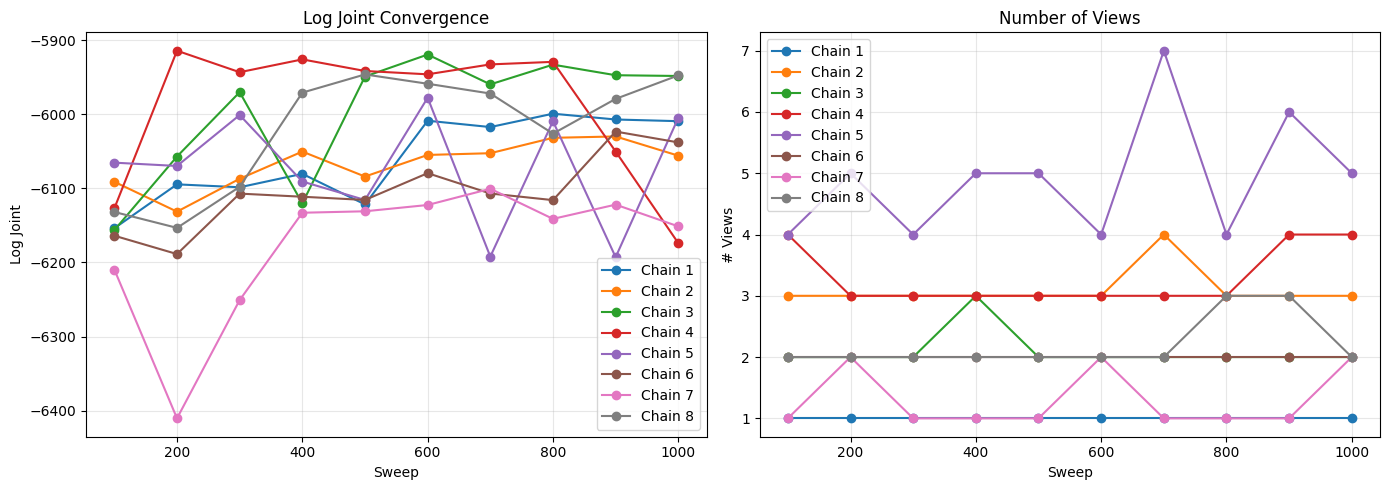

Chain 1: 1 views, clusters per view: [15]
Chain 2: 3 views, clusters per view: [19, 12, 13]
Chain 3: 2 views, clusters per view: [17, 16]
Chain 4: 4 views, clusters per view: [17, 13, 14, 28]
Chain 5: 5 views, clusters per view: [13, 15, 10, 11, 2]
Chain 6: 2 views, clusters per view: [15, 12]
Chain 7: 2 views, clusters per view: [17, 2]
Chain 8: 2 views, clusters per view: [15, 13]


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for c_idx, metrics in enumerate(all_chain_metrics):
    if not metrics:
        continue
    sweeps = [m["sweep"] for m in metrics]
    log_joints = [m["log_joint"] for m in metrics]
    n_views = [m["n_views"] for m in metrics]
    ax1.plot(sweeps, log_joints, marker="o", label=f"Chain {c_idx + 1}")
    ax2.plot(sweeps, n_views, marker="o", label=f"Chain {c_idx + 1}")

ax1.set_xlabel("Sweep")
ax1.set_ylabel("Log Joint")
ax1.set_title("Log Joint Convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Sweep")
ax2.set_ylabel("# Views")
ax2.set_title("Number of Views")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "convergence.png", dpi=150, bbox_inches="tight")
plt.show()

for i, s in enumerate(states):
    clusters = [int(jnp.max(v.row_assignments)) + 1 for v in s.views]
    print(f"Chain {i + 1}: {s.n_views} views, clusters per view: {clusters}")

## 7. Dependence Matrix (Paper Fig 13b) & Pixel Dependence Map (Paper Fig 13c)

The Z-matrix shows pairwise dependence probabilities between all columns.
The paper found two blocks: foreground pixels (dependent on digit) and background pixels (independent).

Z-matrix shape: (257, 257)


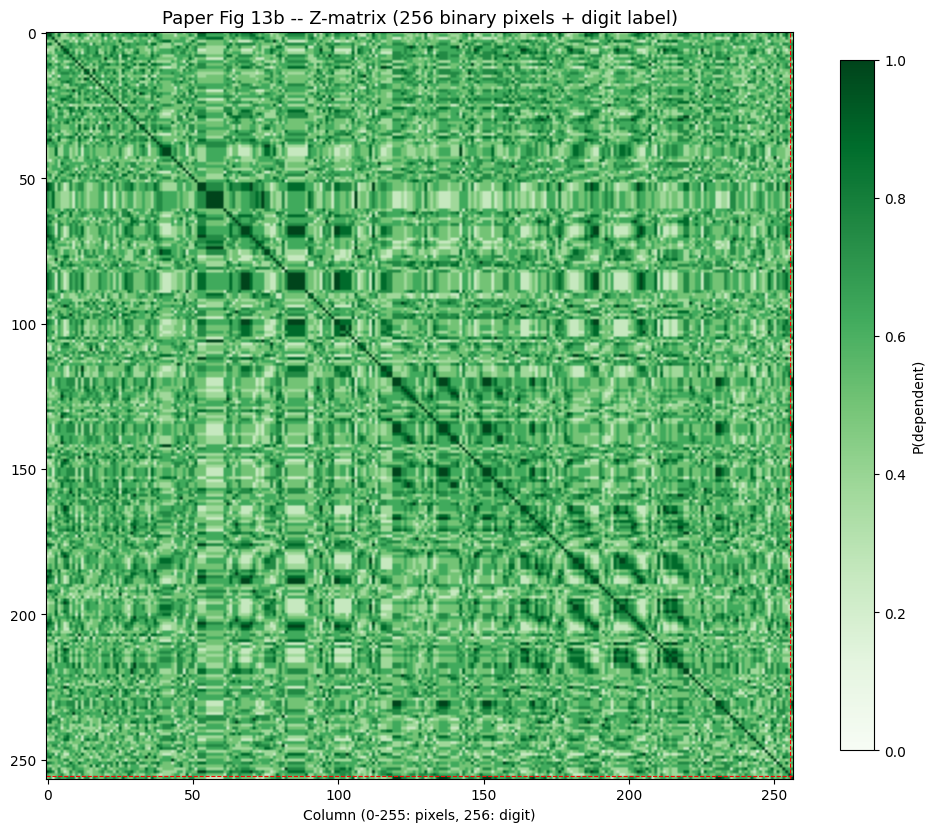

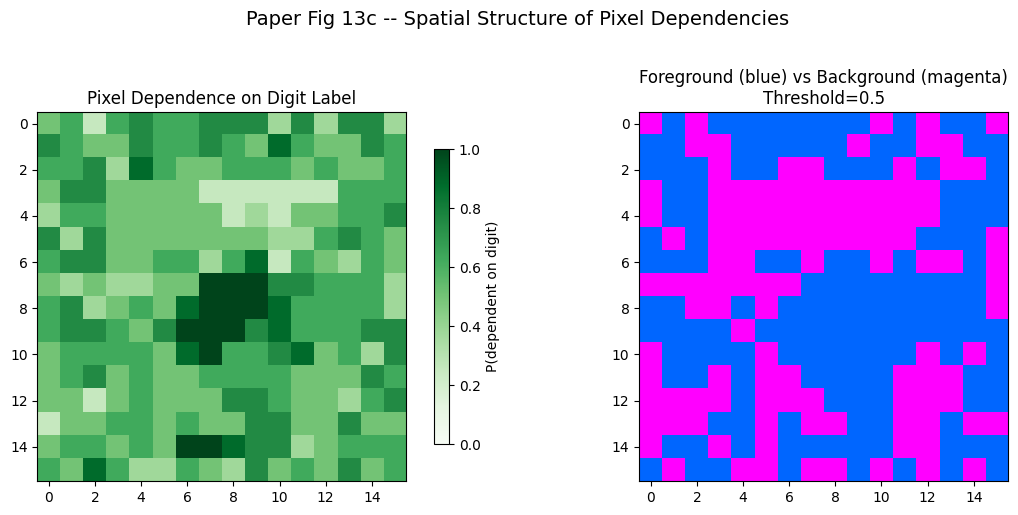

In [8]:
z_matrix = np.array(packed_dependence_matrix(packed_states))
print(f"Z-matrix shape: {z_matrix.shape}")

# --- Fig 13b: Full dependence matrix ---
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(z_matrix, cmap="Greens", vmin=0, vmax=1, aspect="equal")
plt.colorbar(im, ax=ax, label="P(dependent)", shrink=0.8)
ax.axhline(y=N_PIXELS - 0.5, color="red", linewidth=0.8, linestyle="--")
ax.axvline(x=N_PIXELS - 0.5, color="red", linewidth=0.8, linestyle="--")
ax.set_title(f"Paper Fig 13b -- Z-matrix ({N_PIXELS} binary pixels + digit label)", fontsize=13)
ax.set_xlabel(f"Column (0-{N_PIXELS - 1}: pixels, {N_PIXELS}: digit)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "z_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Fig 13c: Pixel dependence spatial map ---
dep_with_digit = z_matrix[:N_PIXELS, N_PIXELS]
dep_map = dep_with_digit.reshape(PIXEL_SIZE, PIXEL_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im = axes[0].imshow(dep_map, cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=axes[0], label="P(dependent on digit)", shrink=0.8)
axes[0].set_title("Pixel Dependence on Digit Label")

threshold = 0.5
fg_bg = np.where(dep_map > threshold, 1.0, 0.0)
cmap_fb = LinearSegmentedColormap.from_list("fb", ["#FF00FF", "#FFFFFF", "#0066FF"], N=256)
axes[1].imshow(fg_bg, cmap=cmap_fb, vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title(f"Foreground (blue) vs Background (magenta)\nThreshold={threshold}")

fig.suptitle("Paper Fig 13c -- Spatial Structure of Pixel Dependencies", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pixel_dependence_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Digit-Cluster Contingency Table

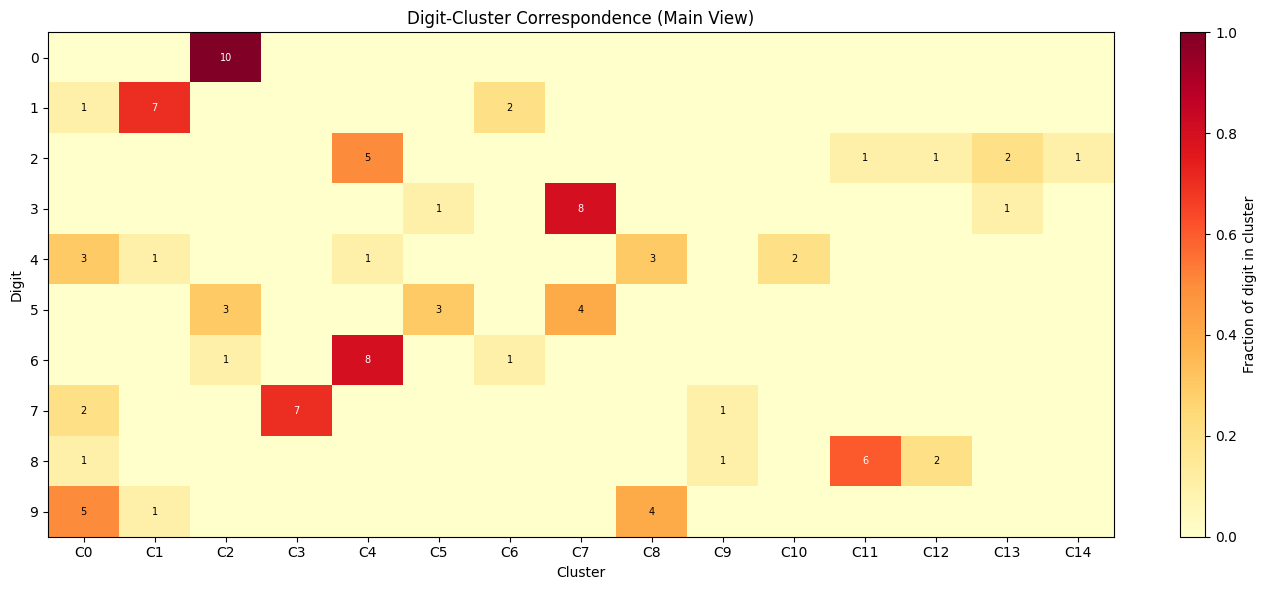

In [9]:
final_state = states[best_idx]
view_sizes = [len(v.column_indices) for v in final_state.views]
main_view = final_state.views[int(np.argmax(view_sizes))]
row_assign = np.array(main_view.row_assignments)
n_clusters = int(row_assign.max()) + 1

contingency = np.zeros((10, n_clusters), dtype=np.int32)
for digit in range(10):
    for c in range(n_clusters):
        contingency[digit, c] = int(np.sum(row_assign[labels == digit] == c))

row_sums = contingency.sum(axis=1, keepdims=True)
normalized = contingency / np.maximum(row_sums, 1)

fig, ax = plt.subplots(figsize=(max(8, n_clusters * 0.8 + 2), 6))
im = ax.imshow(normalized, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of digit in cluster")
ax.set_xticks(range(n_clusters))
ax.set_xticklabels([f"C{i}" for i in range(n_clusters)])
ax.set_yticks(range(10))
ax.set_yticklabels([str(d) for d in range(10)])
ax.set_xlabel("Cluster")
ax.set_ylabel("Digit")
ax.set_title("Digit-Cluster Correspondence (Main View)")
for i in range(10):
    for j in range(n_clusters):
        if contingency[i, j] > 0:
            ax.text(
                j,
                i,
                str(contingency[i, j]),
                ha="center",
                va="center",
                fontsize=7,
                color="white" if normalized[i, j] > 0.5 else "black",
            )
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contingency.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Classification ROC (Paper Fig 15)

Classify digits using posterior predictive P(digit=k | pixels), averaged across all chains.
Compare against SVM baselines (linear and RBF kernels).

Computing CrossCat classification probabilities...
  State 1/8 done in 8.5s
  State 2/8 done in 0.2s
  State 3/8 done in 0.2s
  State 4/8 done in 0.2s
  State 5/8 done in 0.2s
  State 6/8 done in 0.2s
  State 7/8 done in 0.2s
  State 8/8 done in 0.2s

CrossCat accuracy: 0.8900
SVM linear accuracy: 1.0000
SVM RBF accuracy: 0.9700


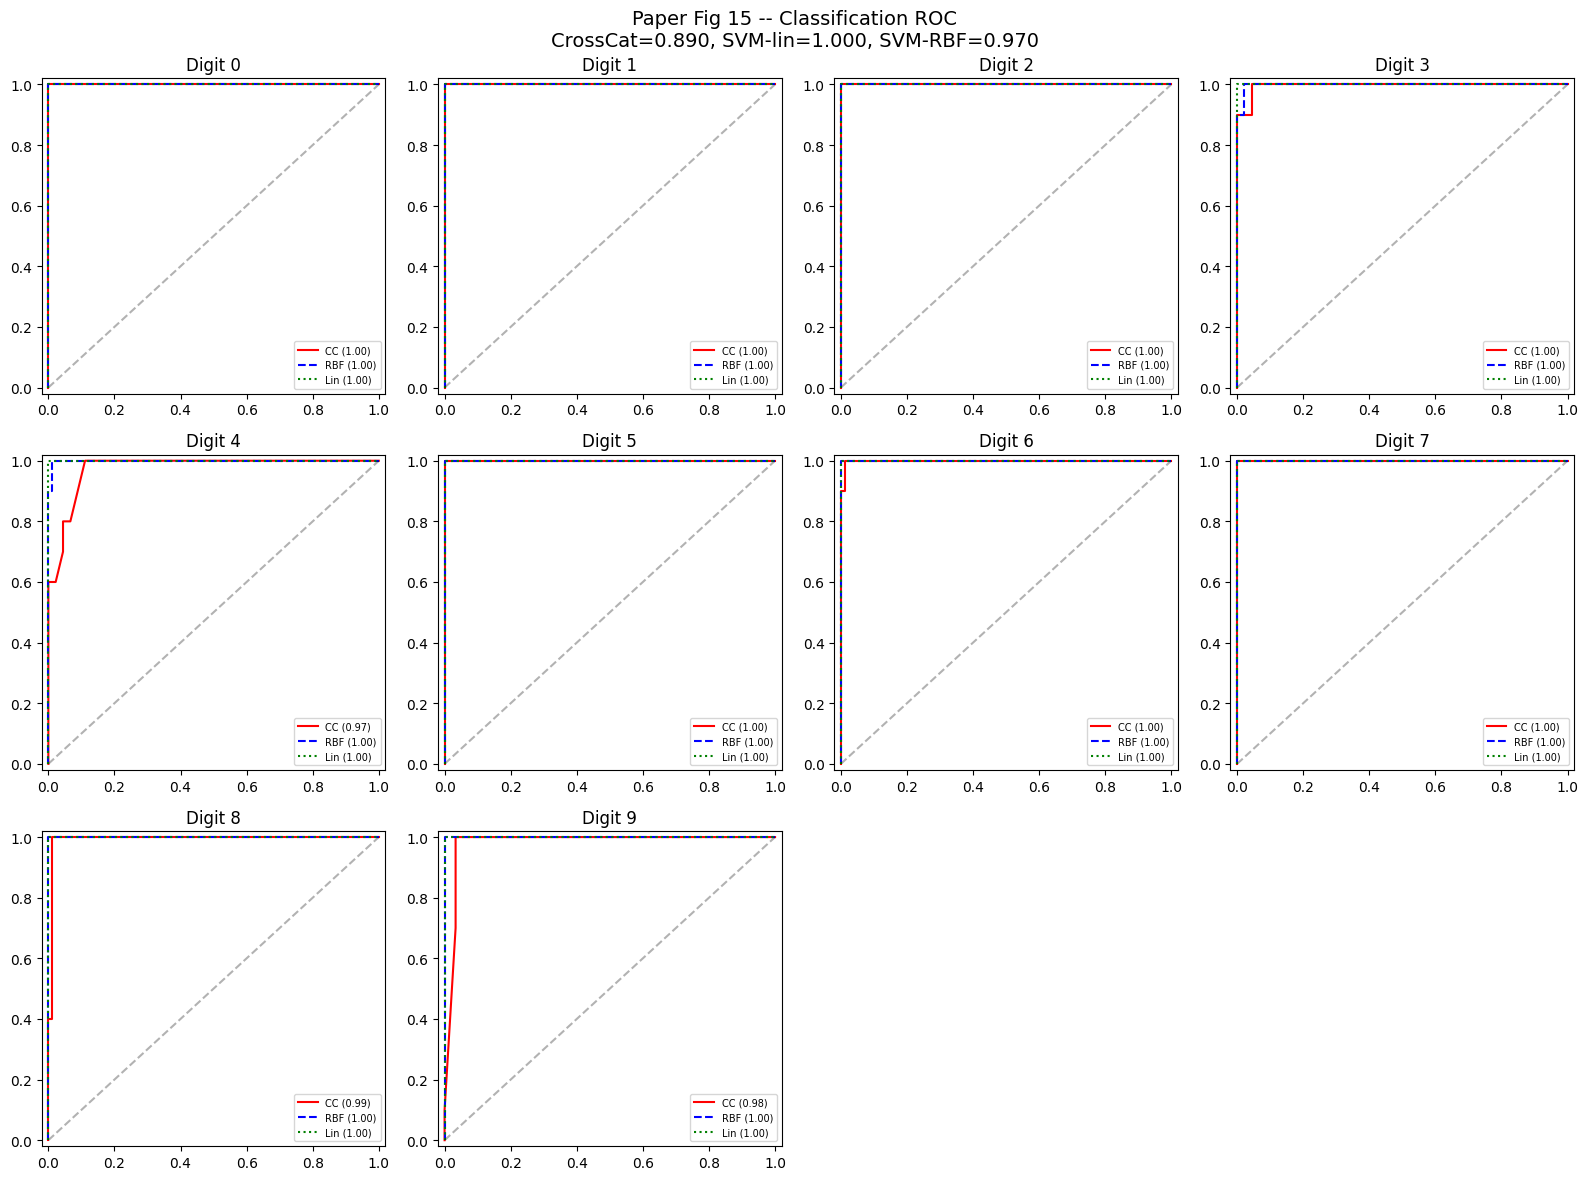

In [10]:
print("Computing CrossCat classification probabilities...")
digit_col = N_PIXELS
all_probs = np.zeros((N_SAMPLES, 10))
candidate_digits = jnp.arange(10, dtype=jnp.float32)
row_ids = jnp.arange(N_SAMPLES)

for s_idx, packed in enumerate(packed_states):
    t0 = time.time()
    logps = batch_classify_column(packed, data_jax, digit_col, candidate_digits, row_ids)
    all_probs += np.array(logps)
    print(f"  State {s_idx + 1}/{len(packed_states)} done in {time.time() - t0:.1f}s")

all_probs /= len(packed_states)
probs_exp = np.exp(all_probs - all_probs.max(axis=1, keepdims=True))
probs_norm = probs_exp / probs_exp.sum(axis=1, keepdims=True)
cc_predicted = np.argmax(probs_norm, axis=1)
cc_acc = np.mean(cc_predicted == labels)

# SVM baselines
pixel_data = data[:, :N_PIXELS]
svm_lin = SVC(kernel="linear", probability=True, random_state=SEED)
svm_lin.fit(pixel_data, labels)
svm_lin_probs = svm_lin.predict_proba(pixel_data)
svm_lin_acc = svm_lin.score(pixel_data, labels)

svm_rbf = SVC(kernel="rbf", probability=True, random_state=SEED)
svm_rbf.fit(pixel_data, labels)
svm_rbf_probs = svm_rbf.predict_proba(pixel_data)
svm_rbf_acc = svm_rbf.score(pixel_data, labels)

print(f"\nCrossCat accuracy: {cc_acc:.4f}")
print(f"SVM linear accuracy: {svm_lin_acc:.4f}")
print(f"SVM RBF accuracy: {svm_rbf_acc:.4f}")

# ROC curves
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes_flat = axes.flatten()
for digit in range(10):
    ax = axes_flat[digit]
    y_true = (labels == digit).astype(int)
    fpr_cc, tpr_cc, _ = roc_curve(y_true, probs_norm[:, digit])
    fpr_lin, tpr_lin, _ = roc_curve(y_true, svm_lin_probs[:, digit])
    fpr_rbf, tpr_rbf, _ = roc_curve(y_true, svm_rbf_probs[:, digit])
    ax.plot(fpr_cc, tpr_cc, "r-", lw=1.5, label=f"CC ({auc(fpr_cc, tpr_cc):.2f})")
    ax.plot(fpr_rbf, tpr_rbf, "b--", lw=1.5, label=f"RBF ({auc(fpr_rbf, tpr_rbf):.2f})")
    ax.plot(fpr_lin, tpr_lin, "g:", lw=1.5, label=f"Lin ({auc(fpr_lin, tpr_lin):.2f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_title(f"Digit {digit}")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
for idx in range(10, 12):
    axes_flat[idx].axis("off")
fig.suptitle(
    f"Paper Fig 15 -- Classification ROC\n"
    f"CrossCat={cc_acc:.3f}, SVM-lin={svm_lin_acc:.3f}, SVM-RBF={svm_rbf_acc:.3f}",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "classification_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Pixel Inpainting (Paper Fig 14)

For one image per digit, mask different fractions of pixels and predict the missing ones
analytically using the posterior predictive.

  0% observed: pixel accuracy=0.0000 (0.0s)
  10% observed: pixel accuracy=0.9381 (12.8s)
  18% observed: pixel accuracy=0.9386 (12.8s)
  30% observed: pixel accuracy=0.9356 (12.4s)


/tmp/ipykernel_2309/4089350755.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


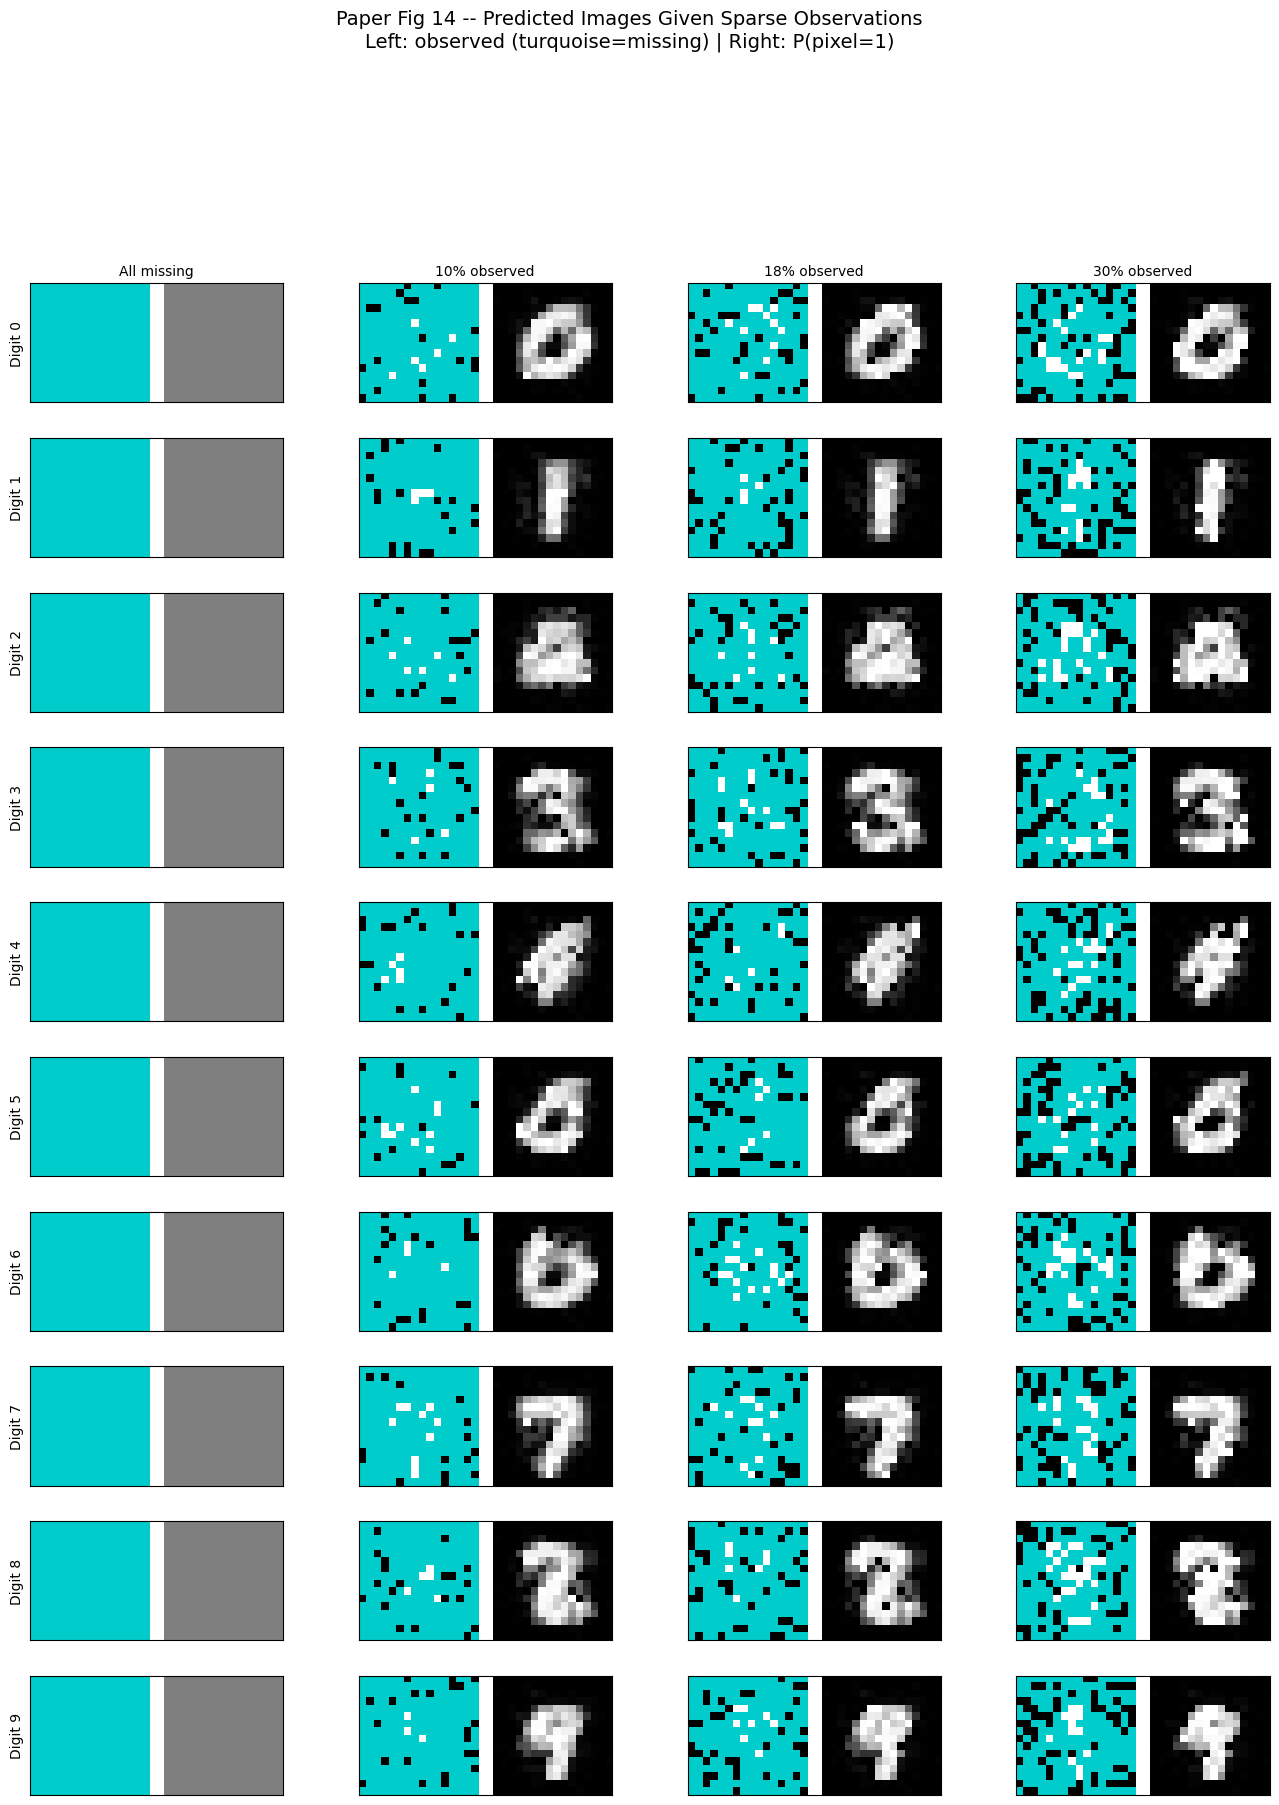

In [11]:
packed = packed_states[best_idx]
rng_inp = np.random.default_rng(SEED + 100)
sample_indices = [np.where(labels == d)[0][0] for d in range(10)]
obs_levels = [0.0, 0.10, 0.18, 0.30]

fig, panel_axes = plt.subplots(
    10, 4, figsize=(16, 20), gridspec_kw={"wspace": 0.3, "hspace": 0.05}
)
inpainting_results = {}

for level_idx, obs_frac in enumerate(obs_levels):
    t0 = time.time()
    level_correct, level_total = 0, 0
    for digit_idx, row_idx in enumerate(sample_indices):
        if obs_frac == 0.0:
            obs_mask = np.zeros(N_PIXELS, dtype=bool)
        else:
            n_obs = int(N_PIXELS * obs_frac)
            perm = rng_inp.permutation(N_PIXELS)
            obs_mask = np.zeros(N_PIXELS, dtype=bool)
            obs_mask[perm[:n_obs]] = True

        miss_cols = np.where(~obs_mask)[0]

        if len(miss_cols) > 0 and obs_mask.any():
            marg = np.full(N_PIXELS, 0.5)
            marg[obs_mask] = data[row_idx, :N_PIXELS][obs_mask]
            miss_cols_jax = jnp.array(miss_cols, dtype=jnp.int32)
            p1_vals = np.array(
                batch_score_columns_binary(packed, data_jax, miss_cols_jax, row_id=row_idx)
            )
            marg[miss_cols] = p1_vals
            pred = (p1_vals > 0.5).astype(float)
            actual = binary_images[row_idx][~obs_mask]
            level_correct += np.sum(pred == actual)
            level_total += len(miss_cols)
        elif not obs_mask.any():
            marg = np.full(N_PIXELS, 0.5)
        else:
            marg = data[row_idx, :N_PIXELS].copy()

        ps = PIXEL_SIZE
        obs_disp = np.full((ps, ps, 3), [0.0, 0.8, 0.8])
        for px in range(N_PIXELS):
            r, c = px // ps, px % ps
            if obs_mask[px]:
                v = data[row_idx, px]
                obs_disp[r, c] = [v, v, v]
        marg_disp = marg.reshape(ps, ps)
        combined = np.ones((ps, ps * 2 + 2, 3))
        combined[:, :ps] = obs_disp
        combined[:, ps + 2 : ps * 2 + 2] = np.stack([marg_disp] * 3, axis=-1)

        ax = panel_axes[digit_idx, level_idx]
        ax.imshow(combined, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        if digit_idx == 0:
            ax.set_title(
                "All missing" if obs_frac == 0 else f"{obs_frac * 100:.0f}% observed",
                fontsize=10,
            )
        if level_idx == 0:
            ax.set_ylabel(f"Digit {digit_idx}", fontsize=10)

    acc = level_correct / max(level_total, 1)
    inpainting_results[f"{obs_frac:.2f}"] = acc
    print(f"  {obs_frac * 100:.0f}% observed: pixel accuracy={acc:.4f} ({time.time() - t0:.1f}s)")

fig.suptitle(
    "Paper Fig 14 -- Predicted Images Given Sparse Observations\n"
    "Left: observed (turquoise=missing) | Right: P(pixel=1)",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "inpainting.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Summary & Export

In [12]:
summary = {
    "config": {
        "pixel_size": PIXEL_SIZE,
        "n_pixels": N_PIXELS,
        "n_samples": N_SAMPLES,
        "n_chains": N_CHAINS,
        "n_sweeps": N_SWEEPS,
        "n_devices": n_devices,
        "use_pmap": USE_PMAP,
        "chains_per_device": CHAINS_PER_DEVICE,
        "backend": str(jax.default_backend()),
        "devices": str(jax.devices()),
    },
    "structure": {
        f"chain_{i + 1}": {
            "n_views": s.n_views,
            "clusters_per_view": [int(jnp.max(v.row_assignments)) + 1 for v in s.views],
            "log_joint": scores[i],
        }
        for i, s in enumerate(states)
    },
    "best_chain": best_idx + 1,
    "classification": {
        "crosscat_accuracy": float(cc_acc),
        "svm_linear_accuracy": float(svm_lin_acc),
        "svm_rbf_accuracy": float(svm_rbf_acc),
    },
    "inpainting": inpainting_results,
}

with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("MNIST PAPER BENCHMARK RESULTS")
print("=" * 60)
print(json.dumps(summary, indent=2))
print("=" * 60)

# Archive to /kaggle/working/ for easy download
import shutil

results_tar = "/kaggle/working/mnist_results.tar.gz"
shutil.make_archive("/kaggle/working/mnist_results", "gztar", ".", str(RESULTS_DIR))
print(f"\nArchived to {results_tar}")
print("Download from Kaggle Output tab.")

for f in sorted(RESULTS_DIR.rglob("*")):
    if f.is_file():
        size = f.stat().st_size
        print(f"  {f.relative_to(RESULTS_DIR)}  ({size:,} bytes)")

MNIST PAPER BENCHMARK RESULTS
{
  "config": {
    "pixel_size": 16,
    "n_pixels": 256,
    "n_samples": 100,
    "n_chains": 8,
    "n_sweeps": 1000,
    "n_devices": 2,
    "use_pmap": true,
    "chains_per_device": 4,
    "backend": "gpu",
    "devices": "[CudaDevice(id=0), CudaDevice(id=1)]"
  },
  "structure": {
    "chain_1": {
      "n_views": 1,
      "clusters_per_view": [
        15
      ],
      "log_joint": -6028.9072265625
    },
    "chain_2": {
      "n_views": 3,
      "clusters_per_view": [
        19,
        12,
        13
      ],
      "log_joint": -6067.86962890625
    },
    "chain_3": {
      "n_views": 2,
      "clusters_per_view": [
        17,
        16
      ],
      "log_joint": -5964.94921875
    },
    "chain_4": {
      "n_views": 4,
      "clusters_per_view": [
        17,
        13,
        14,
        28
      ],
      "log_joint": -6189.9658203125
    },
    "chain_5": {
      "n_views": 5,
      "clusters_per_view": [
        13,
        15,
   